# ScrambleMix quick start

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MADONOKOUKI/psivt23_scramblemix/blob/main/notebooks/quickstart.ipynb)

Official implementation of *ScrambleMix: A Privacy-Preserving Image Processing for Edge-Cloud Machine Learning*
(Madono, Tanaka and Onishi, PSIVT 2023) — [code](https://github.com/MADONOKOUKI/psivt23_scramblemix) ·
[paper](https://doi.org/10.1007/978-981-97-0376-0_25) · [project page](https://madonokouki.github.io/projects/scramblemix/).

ScrambleMix scrambles two copies of an image with the two keys of a secret key pair and mixes them,
`x~ = (1 - m) f(x; k1) + m f(x; k2)` with `m ~ Beta(alpha, alpha)`. This notebook runs on a CPU in a few minutes
and downloads no dataset (LPIPS downloads its AlexNet weights, ~233 MB, on first use).

In [1]:
import subprocess
import sys

if "google.colab" in sys.modules:  # install the package when running on Colab
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/MADONOKOUKI/psivt23_scramblemix"], check=True)

## 1. Scramble and mix an image

`ScrambleMix.random` draws a secret key set (here four key pairs of pixel-based encryption keys for 32x32 images).
`sm.mix(img, pair, m)` applies one key pair with a chosen mixing ratio; calling `sm(img)` samples the key pair and `m`.

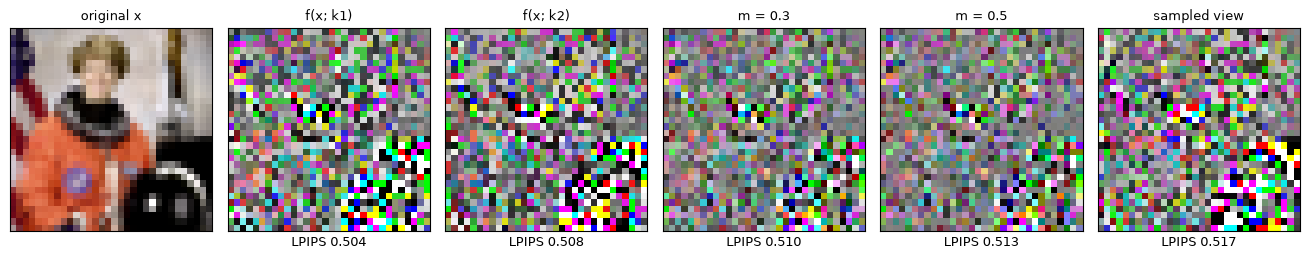

In [2]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
from skimage import data

from scramblemix import ScrambleMix, lpips_distance
from scramblemix._image import as_float_tensor

torch.manual_seed(0)
img = Image.fromarray(data.astronaut()).resize((32, 32), Image.BICUBIC)  # CIFAR-sized example image
sm = ScrambleMix.random(num_pairs=4, key_seed=0, seed=0)  # alpha = 5e-3 as in the paper's code
k1, k2 = sm.pairs[0]
panels = {
    "original x": as_float_tensor(img),
    "f(x; k1)": k1(img).float() / 255,
    "f(x; k2)": k2(img).float() / 255,
    "m = 0.3": sm.mix(img, pair=0, m=0.3),
    "m = 0.5": sm.mix(img, pair=0, m=0.5),
    "sampled view": sm(img),
}
scores = lpips_distance(panels["original x"].expand(5, 3, 32, 32), torch.stack(list(panels.values())[1:]))
fig, axes = plt.subplots(1, len(panels), figsize=(2.2 * len(panels), 2.6))
for i, (ax, (title, im)) in enumerate(zip(axes, panels.items())):
    ax.imshow(im.permute(1, 2, 0).numpy(), interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("" if i == 0 else f"LPIPS {scores[i - 1]:.3f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

With `alpha = 5e-3` (the setting of the paper's code) the sampled `m` is almost always close to 0 or 1:

In [3]:
m = sm.sample_mix_ratio(10000)
print(f"fraction of m in (0.01, 0.99): {((m > 0.01) & (m < 0.99)).mean():.3f}; mean m = {m.mean():.3f}")

fraction of m in (0.01, 0.99): 0.020; mean m = 0.498


## 2. Train a classifier on ScrambleMix views

A toy, learnable 10-class task (the class decides the position and colour of a square) keeps this fast.
Each training image gives **D = 4** views, one per key pair (`ScrambleMixViews`); the loss is cross-entropy plus the
self-teaching loss (`scramblemix_loss`). At test time, clean images are scrambled on the "edge side" and the
predictions for **T = 4** key pairs are averaged (`predict_tta`).

In [4]:
import numpy as np
from torch.utils.data import DataLoader, Dataset

from scramblemix import ScrambleMixViews, predict_tta, scramblemix_loss
from scramblemix.models import WideResNet


def toy_image(label, rng):
    x = rng.integers(0, 80, (32, 32, 3)).astype(np.uint8)
    r, c = divmod(label, 5)
    x[4 + 14 * r:14 + 14 * r, 2 + 6 * c:8 + 6 * c] = [200, 60 + 15 * label, 255 - 20 * label]
    return x


class Toy(Dataset):
    def __init__(self, n, seed, transform=None):
        rng = np.random.default_rng(seed)
        self.labels = [i % 10 for i in range(n)]
        self.images = [Image.fromarray(toy_image(y, rng)) for y in self.labels]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        x = self.images[i]
        return (self.transform(x) if self.transform else x), self.labels[i]


device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(Toy(500, seed=0, transform=ScrambleMixViews(sm)), batch_size=50, shuffle=True)
test = Toy(200, seed=1)
test_images = torch.stack([torch.from_numpy(np.array(x)).permute(2, 0, 1) for x in test.images])  # clean, uint8
test_labels = torch.tensor(test.labels)

epochs = 5
model = WideResNet(depth=10, widen_factor=1, num_classes=10).to(device)  # a tiny network for the toy task
opt = torch.optim.Adam(model.parameters(), lr=2e-3)  # (train.py uses the paper's SGD recipe)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs * len(train_loader))
for epoch in range(epochs):
    model.train()
    for views, labels in train_loader:  # views: [B, D, 3, 32, 32]
        views, labels = views.to(device), labels.to(device)
        logits = torch.stack([model(views[:, d]) for d in range(views.shape[1])])  # [D, B, 10]
        loss = scramblemix_loss(logits, labels, lam=1.0)
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
    model.eval()
    with torch.no_grad():
        single = model(sm(test_images).to(device)).argmax(1).cpu()               # T = 1: one random key pair
    tta = predict_tta(model, test_images, sm, num_keys=4).argmax(1).cpu()          # T = 4 key pairs
    print(f"epoch {epoch + 1}: loss {loss.item():.3f} | test acc T=1 {(single == test_labels).float().mean():.1%}"
          f" | T=4 {(tta == test_labels).float().mean():.1%}")

epoch 1: loss 2.175 | test acc T=1 32.5% | T=4 38.0%


epoch 2: loss 1.905 | test acc T=1 47.0% | T=4 48.5%


epoch 3: loss 1.642 | test acc T=1 87.5% | T=4 92.5%


epoch 4: loss 1.533 | test acc T=1 90.0% | T=4 95.0%


epoch 5: loss 1.478 | test acc T=1 90.0% | T=4 97.0%


## 3. Reproduce the paper

On a GPU machine, clone the repository and run

```bash
bash scripts/reproduce_accuracy.sh   # ScrambleMix on CIFAR-10/100 and SVHN, WideResNet and ShakeDrop (slides 39-40)
bash scripts/reproduce_lpips.sh      # LPIPS of PE / LE / ScrambleMix scrambled test images
```

`python train.py --help` lists all options; the defaults are the paper setting of the original code.